In [1]:
import pandas as pd
import numpy as np

In [2]:
# SFMS
slope = 0.86
intercept=-8.5
def del_SFMS(Mstar, SFR):
    SFMS = slope * Mstar + intercept
    del_SFMS = SFR - SFMS
    return del_SFMS

def is_quenched(del_SFMS):
    if del_SFMS < -0.5:
        return True
    else:
        return False

In [3]:
low_mass_satellite_df = pd.read_parquet ('../../data/low_mass_satellite_df_annuli_revised.parquet')

In [4]:
low_mass_satellite_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
439,37.0,0.174505,8.905776,-0.052619,8.682093,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
440,37.0,0.523516,8.636583,-0.643683,8.302815,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
441,37.0,0.872526,8.421218,-1.414926,7.867777,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
442,37.0,1.221537,8.243556,-1.699316,7.714798,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
443,37.0,1.570547,8.094305,-1.657207,7.711024,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54860,593573.0,0.461125,7.915781,-3.874264,7.566107,1,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,-0.044053,0.168837,1.027657e-321
54861,593573.0,0.768541,7.496673,-2.880743,7.366165,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,-0.044053,0.168837,1.027657e-321
54862,593573.0,1.075957,7.168706,-3.435107,7.380437,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,-0.044053,0.168837,1.027657e-321
54863,593573.0,1.383374,6.925375,-3.566125,7.352052,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,-0.044053,0.168837,1.027657e-321


In [5]:
# # calculating star forming efficiency (SFE) and gas fraction 
# low_mass_satellite_df['SFE'] = 10**(low_mass_satellite_df['avg_SFR'] - low_mass_satellite_df['avg_gas_mass'])
# low_mass_satellite_df['f_gas'] = 10**(low_mass_satellite_df['avg_gas_mass'] - low_mass_satellite_df['avg_s_mass'])

In [6]:
# # remove the rows where the sfr_indicator is 0.0 -> implies artificially imposed minimum
# low_mass_satellite_df = low_mass_satellite_df[low_mass_satellite_df['sfr_indicator'] != 0.0]
# low_mass_satellite_df

In [7]:
high_mass_satellite_df = pd.read_parquet ('../../data/high_mass_satellite_df_annuli_revised.parquet')
all_satellites_df = pd.concat([low_mass_satellite_df, high_mass_satellite_df], ignore_index=True)
print('length of all satellites df:', len(all_satellites_df))

# --- remove quenched galaxies using del_SFMS and is_quenched ---
# del_SFMS takes (Mstar, SFR) -> use 's_mass' and 'global_SFRs' columns
all_satellites_df['del_SFMS'] = del_SFMS(all_satellites_df['s_mass'], all_satellites_df['global_SFRs'])

# is_quenched expects the del_SFMS value
quenched_mask = all_satellites_df['del_SFMS'].apply(is_quenched)
removed = quenched_mask.sum()
all_satellites_df = all_satellites_df[~quenched_mask].reset_index(drop=True)
print(f"Removed {removed} quenched rows; remaining {len(all_satellites_df)} rows.")

# drop helper column
all_satellites_df = all_satellites_df.drop(columns=['del_SFMS'])
print(f"filtered dataframe has {len(all_satellites_df)} rows.")


length of all satellites df: 14506
Removed 2883 quenched rows; remaining 11623 rows.
filtered dataframe has 11623 rows.


In [8]:
all_satellites_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
0,37.0,0.174505,8.905776,-0.052619,8.682093,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8.761890e+03,0.0,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
1,37.0,0.523516,8.636583,-0.643683,8.302815,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8.761890e+03,0.0,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
2,37.0,0.872526,8.421218,-1.414926,7.867777,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8.761890e+03,0.0,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
3,37.0,1.221537,8.243556,-1.699316,7.714798,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8.761890e+03,0.0,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
4,37.0,1.570547,8.094305,-1.657207,7.711024,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8.761890e+03,0.0,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11618,476528.0,0.179965,9.485483,-2.459436,7.232764,1,0.000000,3.387989,0.010589,1,112.132950,0.018142,1.015537e+06,0.0,121.820320,6.780018,0.403195,0.133146,1.015537e+06
11619,476528.0,0.539895,9.195900,-2.790333,6.889097,1,0.000000,3.387989,0.010589,1,112.132950,0.018142,1.015537e+06,0.0,121.820320,6.780018,0.403195,0.133146,1.015537e+06
11620,476528.0,0.899825,8.818249,-3.192451,6.611662,1,0.000000,3.387989,0.010589,1,112.132950,0.018142,1.015537e+06,0.0,121.820320,6.780018,0.403195,0.133146,1.015537e+06
11621,476528.0,1.259755,8.497334,-3.498477,6.271559,1,0.000000,3.387989,0.010589,1,112.132950,0.018142,1.015537e+06,0.0,121.820320,6.780018,0.403195,0.133146,1.015537e+06


In [9]:
# star forming quenching vector value = 0
all_satellites_df = all_satellites_df[all_satellites_df['quenching_vector'] != 1]
all_satellites_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
0,37.0,0.174505,8.905776,-0.052619,8.682093,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.0,38878.035156,202.795135,-0.682291,0.694089,8761.889648
1,37.0,0.523516,8.636583,-0.643683,8.302815,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.0,38878.035156,202.795135,-0.682291,0.694089,8761.889648
2,37.0,0.872526,8.421218,-1.414926,7.867777,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.0,38878.035156,202.795135,-0.682291,0.694089,8761.889648
3,37.0,1.221537,8.243556,-1.699316,7.714798,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.0,38878.035156,202.795135,-0.682291,0.694089,8761.889648
4,37.0,1.570547,8.094305,-1.657207,7.711024,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.0,38878.035156,202.795135,-0.682291,0.694089,8761.889648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11613,462987.0,0.173652,9.171778,-0.202319,8.651024,0,0.000000,2.001361,0.003254,1,83.934608,2.233273,75.523567,0.0,129.809052,0.046284,-1.015946,0.104524,75.523567
11614,462987.0,0.520957,8.854676,-0.765807,8.399230,0,0.000000,2.001361,0.003254,1,83.934608,2.233273,75.523567,0.0,129.809052,0.046284,-1.015946,0.104524,75.523567
11615,462987.0,0.868261,8.582487,-1.080499,8.100421,0,0.000000,2.001361,0.003254,1,83.934608,2.233273,75.523567,0.0,129.809052,0.046284,-1.015946,0.104524,75.523567
11616,462987.0,1.215566,8.400651,-1.433384,7.964696,0,0.000000,2.001361,0.003254,1,83.934608,2.233273,75.523567,0.0,129.809052,0.046284,-1.015946,0.104524,75.523567


In [10]:
all_satellites_df.shape

(6891, 19)

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import RobustScaler

# 'BHMass', 'BHCum_QM', 'Mhalo', 'overdens', and 'bulge' are the features wer are testing
all_satellites_df = all_satellites_df.drop(columns=["class", "BH_cumQM", "BH_cumRM", "global_SFRs", "gas_mass","avg_gas_mass", "quenching_vector", "Bfld", "veldisp", "BH_AGN", "bulge"])

<Axes: >

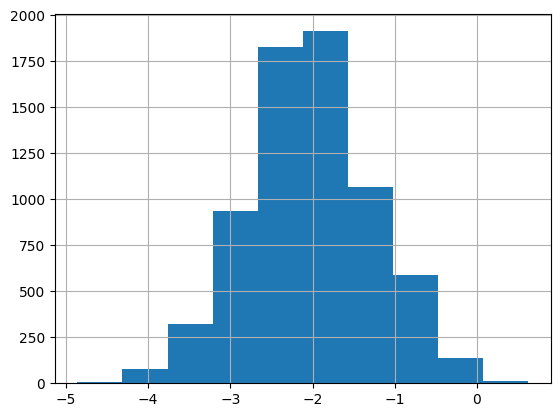

In [12]:
all_satellites_df['avg_SFR'].hist()

In [13]:
# this indicates that there are more instances of the delta rate on the left

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

galaxy_ids = all_satellites_df['subID']

feature_importances_list = []
feature_names = None
test_mses = []
train_mses = []


for seed in range(10):
    # split galaxies into 50% training and 50% testing
    unique_galaxies = np.unique(all_satellites_df['subID'])
    train_galaxies, test_galaxies = train_test_split(unique_galaxies, test_size=0.5, random_state=seed)

    # assign spaxels based on galaxy split
    train_data = all_satellites_df[all_satellites_df['subID'].isin(train_galaxies)]
    test_data = all_satellites_df[all_satellites_df['subID'].isin(test_galaxies)]

    X_train, y_train = train_data.drop(columns=['avg_SFR', 'subID']), train_data['avg_SFR']
    X_test, y_test = test_data.drop(columns=['avg_SFR', 'subID']), test_data['avg_SFR']
    
    
    if feature_names is None:
        feature_names = X_train.columns.tolist()

    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    param_grid = {
    'n_estimators': [100,200, 300, 400, 500],  
    'max_depth': [50, 100, 150, 200, 250],  
    'min_samples_split': [100, 150, 200],  
    'min_samples_leaf': [300, 400, 500, 600],  
    'max_features': [None], 
    'bootstrap': [True],
    }
    rf_regressor = RandomForestRegressor(random_state=seed, n_jobs=-1)
    cv = KFold(n_splits=5, shuffle=True, random_state=seed)

    random_search = RandomizedSearchCV(
    estimator=rf_regressor, 
    param_distributions=param_grid, 
    n_iter=10,
    cv=cv, 
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=seed,
    verbose=2)

    random_search.fit(X_train_scaled, y_train)

    best_rf_regressor = random_search.best_estimator_

    best_rf_regressor.fit(X_train_scaled, y_train)
    
    y_train_pred = best_rf_regressor.predict(X_train_scaled)
    y_test_pred = best_rf_regressor.predict(X_test_scaled)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    train_mses.append(train_mse)
    test_mses.append(test_mse)
    
    feature_importances_list.append(best_rf_regressor.feature_importances_)
#     print(random_search.best_params_)
    print(f"Run {seed+1}: Train MSE = {train_mse:.4f}, Test MSE = {test_mse:.4f}")

print("\nAverage MSE over 10 runs:")
print(f"Train MSE: Mean = {np.mean(train_mses):.4f}, Std = {np.std(train_mses):.4f}")
print(f"Test MSE:  Mean = {np.mean(test_mses):.4f}, Std = {np.std(test_mses):.4f}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Run 1: Train MSE = 0.3276, Test MSE = 0.3536
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Run 2: Train MSE = 0.3331, Test MSE = 0.3439
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Run 3: Train MSE = 0.3319, Test MSE = 0.3502
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Run 4: Train MSE = 0.3206, Test MSE = 0.3677
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Run 5: Train MSE = 0.3468, Test MSE = 0.3344
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Run 6: Train MSE = 0.3275, Test MSE = 0.3489
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Run 7: Train MSE = 0.3371, Test MSE = 0.3455
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Run 8: Train MSE = 0.3381, Test MSE = 0.3385
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Run 9: Train MSE = 0.3407, Test MSE = 0.3479
Fitting 5 folds for each of 10 candidates, tot


=== Average Feature Importances ===
      Feature  Mean Importance   Std Dev
1  avg_s_mass         0.938902  0.010875
3      BHMass         0.042241  0.012853
2      s_mass         0.014048  0.008529
0   bin_radii         0.004190  0.005158
5    overdens         0.000335  0.000361
4       Mhalo         0.000284  0.000284


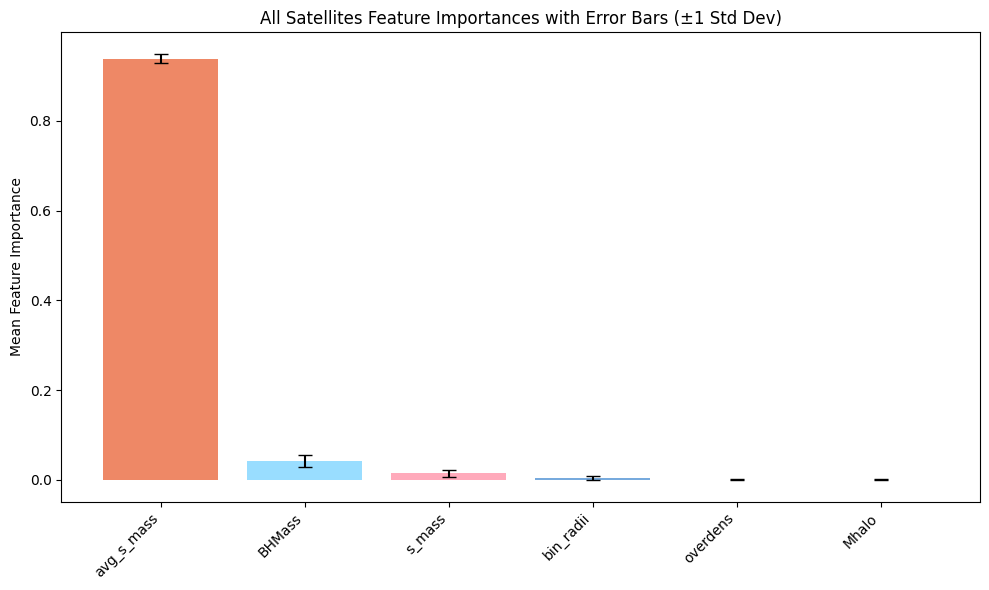

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
feature_colors = {
    'bin_radii': '#77AADD',
    'avg_s_mass': '#EE8866',
    's_mass': '#FFAABB',
    'BHMass': '#99DDFF',
    'Mhalo': '#44BB99',
    'overdens': '#BBCC33',
    'bulge': '#AAAA00',
    'BH_AGN': '#DDDDDD',
}

# importances + stds across 10 runs
importances_array = np.array(feature_importances_list)
importance_means = np.mean(importances_array, axis=0)
importance_stds = np.std(importances_array, axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean Importance': importance_means,
    'Std Dev': importance_stds
}).sort_values(by='Mean Importance', ascending=False)

print("\n=== Average Feature Importances ===")
print(importance_df)

colors = [feature_colors[feat] for feat in importance_df['Feature']]
# Plot
plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Mean Importance'], yerr=importance_df['Std Dev'], capsize=5, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Mean Feature Importance")
plt.title("All Satellites Feature Importances with Error Bars (±1 Std Dev)")
plt.tight_layout()
plt.show()

In [16]:
all_satellites_df.corr()

,subID,bin_radii,avg_s_mass,avg_SFR,s_mass,BHMass,Mhalo,overdens
subID,1.000000,0.023093,-0.203562,-0.046222,-0.328966,-0.325139,-0.757520,-0.118734
bin_radii,0.023093,1.000000,-0.758969,-0.482988,0.037349,0.013883,-0.033665,0.000076
avg_s_mass,-0.203562,-0.758969,1.000000,0.574683,0.327887,0.343574,0.126593,0.074896
avg_SFR,-0.046222,-0.482988,0.574683,1.000000,-0.007768,-0.022281,0.011501,0.059910
s_mass,-0.328966,0.037349,0.327887,-0.007768,1.000000,0.899623,0.146923,0.341235
BHMass,-0.325139,0.013883,0.343574,-0.022281,0.899623,1.000000,0.160125,0.292704
Mhalo,-0.757520,-0.033665,0.126593,0.011501,0.146923,0.160125,1.000000,0.029274
overdens,-0.118734,0.000076,0.074896,0.059910,0.341235,0.292704,0.029274,1.000000


In [17]:
import os
# Define your directory and file name
directory = 'rf_regression_outputs'
filename = 'all_satellites_rf_reg.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
importance_df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

DataFrame saved to rf_regression_outputs\all_satellites_rf_reg.csv


In [18]:
train_mean = round(np.mean(train_mses), 2)
test_mean = round(np.mean(test_mses), 2)

df = pd.DataFrame({
    'Train MSE': [train_mean],
    'Test MSE': [test_mean]
})

print(df)
import os
# Define your directory and file name
directory = 'rf_regression_outputs'
filename = 'all_satellites_rf_reg_mse.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

   Train MSE  Test MSE
0       0.33      0.35
DataFrame saved to rf_regression_outputs\all_satellites_rf_reg_mse.csv


In [22]:
#compare MSE to standard deviation of the target variable (avg_SFR)
mse_mean = np.mean(test_mses)
target_std = all_satellites_df['avg_SFR'].std()
target_var = all_satellites_df['avg_SFR'].var()
print(f"Mean Test MSE: {mse_mean:.4f}")
print(f"Standard Deviation of avg_SFR: {target_std:.4f}")
print(f"Variance of avg_SFR: {target_var:.4f}")

Mean Test MSE: 0.3466
Standard Deviation of avg_SFR: 0.7597
Variance of avg_SFR: 0.5771
